# Train and evaluate the LightGBM viral origin classifier

In [1]:
! pip install lightgbm pandas polars scikit-optimize scikit-learn joblib seaborn matplotlib --quiet

## Model training

When `best_params == None`, the optimal hyperparameters (chosen based on a Bayesian search cross a parameter grid that yields the best AUPRC score of the validation set) are automatically determined. For the combined geNomad/proGenomes/proMGE training dataset, this took about 4 hours 30 minutes. If this was already done once and the model is re-trained for fine tuning or threshold selection, the pre-determined parameters can be provided using the `best_params` argument, which will skip the hyperparameter selection and save a lot of time.

The script `train_eval_lgbm.py` located in `accessory_scripts` will be used for this.

In [1]:
from pathlib import Path
SCRIPTS_DIR = Path("./accessory_scripts")
ROOT_DIR = Path("/storage2/scratch/kosmopoulos/projects/checkAMG/training_data")
SPLIT_DIR = ROOT_DIR.joinpath("train_test_splits")
LGBM_DIR = ROOT_DIR.parent.joinpath("lgbm")
LGBM_DIR.mkdir(exist_ok=True)

In [2]:
BEST_PARAMS_PATH = LGBM_DIR.joinpath("lgbm_train_eval.best_params.json")
LGBM_PKL = LGBM_DIR.joinpath("lgbm_train_eval.pkl")

In [4]:
! python3 {SCRIPTS_DIR.joinpath("train_eval_lgbm.py")} \
    --dataset-path {SPLIT_DIR} \
    --input-format parquet \
    --threads 50 \
    --weights 3.0,1.0,1.0 \
    --high-recall-target 0.50 \
    --med-recall-target 0.90 \
    --high-precision-target 0.95 \
    --med-precision-target 0.90 \
    --med-precision-floor test_provirus:0.90 \
    --high-precision-floor test_provirus:0.95 \
    --output {LGBM_PKL} \
    --best-params {BEST_PARAMS_PATH}

2026-07-11 15:02:43 | LOADING TRAIN AND TEST TABLES
2026-07-11 15:02:43 | Loading test_equal_pos from /storage2/scratch/kosmopoulos/projects/checkAMG/training_data/train_test_splits/test_equal_pos.parquet
2026-07-11 15:02:44 | test_equal_pos: extra columns not expected: ['contig_left_end_dist', 'contig_right_end_dist', 'contig_left_end_gene_dist', 'contig_right_end_gene_dist', 'LGBM_viral_prob', 'Viral_Origin_Confidence', 'viral_region_id', 'step5_in_merged_region', 'region_label', 'region_contig_type', 'True Negative', 'original_region_label', 'Dataset']
2026-07-11 15:02:44 | Loading test_equal_source from /storage2/scratch/kosmopoulos/projects/checkAMG/training_data/train_test_splits/test_equal_source.parquet
2026-07-11 15:02:44 | test_equal_source: extra columns not expected: ['contig_left_end_dist', 'contig_right_end_dist', 'contig_left_end_gene_dist', 'contig_right_end_gene_dist', 'LGBM_viral_prob', 'Viral_Origin_Confidence', 'viral_region_id', 'step5_in_merged_region', 'region_la

## Model evaluation

In [3]:
import os
os.environ["POLARS_MAX_THREADS"] = str(50)
import polars as pl
pl.Config.set_fmt_str_lengths(100)

polars.config.Config

In [4]:
import sys
import pickle
import json

sys.path.append(SCRIPTS_DIR.as_posix())
from train_eval_lgbm import ViralConfidencePredictor

In [5]:
results = pickle.load(open(LGBM_DIR.joinpath("lgbm_train_eval.pkl"), "rb"))
best_params = json.load(open(LGBM_DIR.joinpath("lgbm_train_eval.best_params.json"), "r"))
best_params = {
    'best_config': results["training_results"]["model_config"],
    'best_score': results["training_results"]["cv_score"],
}

In [6]:
best_params

{'best_config': {'colsample_bytree': 0.8027298555765299,
  'learning_rate': 0.1791680537147357,
  'max_bin': 254,
  'max_depth': 12,
  'min_gain_to_split': 0.730097448106751,
  'n_estimators': 641,
  'num_leaves': 256,
  'reg_alpha': 2.0,
  'reg_lambda': 0.046724231521327673,
  'subsample': 0.9741076677786547,
  'subsample_freq': 7},
 'best_score': 0.9614021807492167}

In [7]:
summary_table = results['summary_df']
model_info = results['model_summary'] 
detailed_results = results['evaluation_results']
model = results['trained_model']

In [8]:
model_info

{'training_dataset': 'train',
 'feature_names': ['Pfam_V-score',
  'Pfam_VL-score',
  'KEGG_V-score',
  'KEGG_VL-score',
  'PHROG_V-score',
  'PHROG_VL-score',
  'contig_avg_KEGG_V-score',
  'contig_avg_KEGG_VL-score',
  'contig_avg_Pfam_V-score',
  'contig_avg_Pfam_VL-score',
  'contig_avg_PHROG_V-score',
  'contig_avg_PHROG_VL-score',
  'window_avg_KEGG_VL-score',
  'window_avg_Pfam_VL-score',
  'window_avg_PHROG_VL-score',
  'KEGG_viral_left_dist',
  'KEGG_viral_right_dist',
  'Pfam_viral_left_dist',
  'Pfam_viral_right_dist',
  'PHROG_viral_left_dist',
  'PHROG_viral_right_dist',
  'KEGG_MGE_left_dist',
  'KEGG_MGE_right_dist',
  'Pfam_MGE_left_dist',
  'Pfam_MGE_right_dist',
  'PHROG_MGE_left_dist',
  'PHROG_MGE_right_dist',
  'KEGG_V-score_left_MGE',
  'KEGG_V-score_right_MGE',
  'KEGG_VL-score_left_MGE',
  'KEGG_VL-score_right_MGE',
  'Pfam_V-score_left_MGE',
  'Pfam_V-score_right_MGE',
  'Pfam_VL-score_left_MGE',
  'Pfam_VL-score_right_MGE',
  'PHROG_V-score_left_MGE',
  'PHROG

In [10]:
OUTPUT_TABLES_DIR = Path("./tables/lgbm")
OUTPUT_TABLES_DIR.mkdir(exist_ok=True, parents=True)

In [12]:
model_info["feature_importance"].to_csv(OUTPUT_TABLES_DIR.joinpath("lgbm_feature_importance.tsv"), index=False, sep="\t")

In [11]:
summary_table

,Dataset,Viral_Fraction,MGE_Fraction,Host_Fraction,Confidence_Level,Threshold,Predictions_Made,Accuracy,Balanced_Accuracy,TPR,TNR,Precision,Recall,F1_Score,FDR,MCC,Meets_FDR_Target,Meets_Recall_Target
0,test_near_all_host,5.5%,5.0%,89.5%,High Confidence,0.910,21773,0.973,0.776,0.557,0.996,0.875,0.557,0.680,0.125,0.686,False,True
1,test_near_all_host,5.5%,5.0%,89.5%,Medium Confidence,0.454,84361,0.907,0.867,0.823,0.911,0.334,0.823,0.475,0.666,0.488,False,True
2,test_near_all_host,5.5%,5.0%,89.5%,Low Confidence,0.000,667539,0.051,0.500,1.000,0.000,0.051,1.000,0.098,0.949,0.000,False,True
3,test_mge_enriched,10.3%,75.0%,14.7%,High Confidence,0.910,9379,0.946,0.714,0.443,0.985,0.702,0.443,0.543,0.298,0.532,False,False
4,test_mge_enriched,10.3%,75.0%,14.7%,Medium Confidence,0.454,27767,0.906,0.853,0.791,0.915,0.423,0.791,0.551,0.577,0.535,False,True
5,test_mge_enriched,10.3%,75.0%,14.7%,Low Confidence,0.000,203839,0.073,0.500,1.000,0.000,0.073,1.000,0.136,0.927,0.000,False,True
6,test_host_enriched,16.9%,12.5%,70.6%,High Confidence,0.910,33331,0.927,0.796,0.599,0.994,0.953,0.599,0.735,0.047,0.721,True,True
7,test_host_enriched,16.9%,12.5%,70.6%,Medium Confidence,0.454,69967,0.918,0.918,0.918,0.918,0.696,0.918,0.792,0.304,0.753,False,True
8,test_host_enriched,16.9%,12.5%,70.6%,Low Confidence,0.000,313192,0.169,0.500,1.000,0.000,0.169,1.000,0.290,0.831,0.000,False,True
9,test_equal_source,33.3%,33.3%,33.4%,High Confidence,0.910,42578,0.881,0.824,0.658,0.990,0.968,0.658,0.783,0.032,0.731,True,True


In [13]:
summary_table.to_csv(OUTPUT_TABLES_DIR.joinpath("lgbm_benchmark_summary_table.tsv"), index=False, sep="\t")

### Plot AUPRC and AUROC

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

name_map = {
    "test_near_all_virus": "Near all virus",
    "test_virus_enriched": "Virus enriched",
    "test_input": "Training distribution",
    "test_equal_pos": "Equal viral/nonviral",
    "test_half_virus_host": "Half viral/host",
    "test_equal_source": "Equal viral/MGE/host",
    "test_mge_enriched": "MGE enriched",
    "test_host_enriched": "Host enriched",
    "test_near_all_mge": "Near all MGE",
    "test_near_all_host": "Near all host",
    "test_provirus": "Integrated proviruses",
}

marker_map = {"High Confidence": "o", "Medium Confidence": "s", "Low Confidence": "v"}
conf_order = ["High Confidence", "Medium Confidence", "Low Confidence"]

def _display_name(internal_key):
    return name_map.get(internal_key, internal_key)

def _stable_color_map(labels, palette="tab10", reverse=True):
    labels = sorted(labels)
    cols = sns.color_palette(palette, n_colors=len(labels))
    if reverse:
        cols = list(reversed(cols))
    cols = [(*c, 1.0) for c in cols]
    return dict(zip(labels, cols))

def _confidence_triplet(res):
    return {
        "High Confidence": (res["high_confidence"]["recall"], res["high_confidence"]["precision"]),
        "Medium Confidence": (res["medium_confidence"]["recall"], res["medium_confidence"]["precision"]),
        "Low Confidence": (res["low_confidence"]["recall"], res["low_confidence"]["precision"]),
    }

def _legend_order_pr(evals):
    items = []
    for internal, res in evals.items():
        disp = _display_name(internal)
        auprc = float(res["pr_curve"]["auprc"])
        items.append((disp, auprc))
    items.sort(key=lambda x: x[1], reverse=True)
    return [d for d, _ in items]

def _legend_order_roc(evals):
    items = []
    for internal, res in evals.items():
        disp = _display_name(internal)
        auroc = float(res["roc_curve"]["auroc"])
        items.append((disp, auroc))
    items.sort(key=lambda x: x[1], reverse=True)
    return [d for d, _ in items]

def _reliability_skill(prob_pred, prob_true):
    if len(prob_pred) == 0 or len(prob_true) == 0:
        return float("nan")
    pairs = sorted(zip(prob_pred, prob_true), key=lambda x: x[0])
    xs = [p[0] for p in pairs]
    ys = [p[1] for p in pairs]
    area = 0.0
    for i in range(1, len(xs)):
        x0, x1 = xs[i - 1], xs[i]
        y0, y1 = ys[i - 1], ys[i]
        dx = x1 - x0
        area += dx * (((y0 - x0) + (y1 - x1)) / 2.0)
    return area

def _legend_order_reliability(evals):
    items = []
    for internal, res in evals.items():
        disp = _display_name(internal)
        prob_true = res["reliability"]["prob_true"]
        prob_pred = res["reliability"]["prob_pred"]
        score = _reliability_skill(prob_pred, prob_true)
        items.append((disp, score))
    items.sort(key=lambda x: (x[1] != x[1], x[1]), reverse=True)
    return [d for d, _ in items]

def _common_labels(evals):
    return [_display_name(k) for k in evals.keys()]

def plot_pr_from_results(complete_results, savepath=None, figsize=(8, 4.5)):
    evals = complete_results["evaluation_results"]
    labels = _common_labels(evals)
    colors = _stable_color_map(labels)
    ordered_labels = _legend_order_pr(evals)

    fig, ax = plt.subplots(figsize=figsize)
    ax.axhline(0.90, color="gray", linestyle=":", linewidth=2, alpha=0.4, zorder=0)
    ax.axhline(0.95, color="gray", linestyle="--", linewidth=2, alpha=0.4, zorder=0)

    dataset_handles = {}
    for internal, res in evals.items():
        disp = _display_name(internal)
        color = colors.get(disp, "C0")

        prec = res["pr_curve"]["precision"]
        rec = res["pr_curve"]["recall"]
        auprc = float(res["pr_curve"]["auprc"])

        (line,) = ax.plot(
            rec, prec,
            label=f"{disp} (AUPRC={auprc:.3f})",
            linewidth=2, color=color, alpha=0.85
        )
        dataset_handles[disp] = line

        pts = _confidence_triplet(res)
        for cname in conf_order:
            r, p = pts[cname]
            ax.scatter(
                r, p, marker=marker_map[cname], color=color,
                alpha=0.85, s=70, edgecolor="black", zorder=3
            )

    conf_legend = ax.legend(
        handles=[Line2D([0], [0], marker=marker_map[c], linestyle="None",
                        markerfacecolor="gray", markeredgecolor="black",
                        markersize=9, label=c) for c in conf_order],
        title="Confidence Level", loc="lower left"
    )
    ds_legend = ax.legend(
        handles=[dataset_handles[k] for k in ordered_labels if k in dataset_handles],
        title="Dataset", ncol=1, frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1.0)
    )
    ax.add_artist(conf_legend)
    fig.add_artist(ds_legend)

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=600, bbox_inches="tight")
    plt.show()

def plot_roc_from_results(complete_results, savepath=None, figsize=(8, 4.5)):
    evals = complete_results["evaluation_results"]
    labels = _common_labels(evals)
    colors = _stable_color_map(labels)
    ordered_labels = _legend_order_roc(evals)

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, color="gray", alpha=0.4, zorder=0)

    dataset_handles = {}
    for internal, res in evals.items():
        disp = _display_name(internal)
        color = colors.get(disp, "C0")

        fpr = res["roc_curve"]["fpr"]
        tpr = res["roc_curve"]["tpr"]
        auroc = float(res["roc_curve"]["auroc"])

        (line,) = ax.plot(fpr, tpr, label=f"{disp} (AUROC={auroc:.3f})", color=color, alpha=0.9)
        dataset_handles[disp] = line

        for cname, key in [("High Confidence", "high_confidence"),
                           ("Medium Confidence", "medium_confidence"),
                           ("Low Confidence", "low_confidence")]:
            tpr_pt = res[key]["tpr"]
            fpr_pt = 1.0 - res[key]["tnr"]
            ax.scatter(
                fpr_pt, tpr_pt, marker=marker_map[cname], color=color,
                alpha=0.85, s=70, edgecolor="black", zorder=3
            )

    conf_legend = ax.legend(
        handles=[Line2D([0], [0], marker=marker_map[c], linestyle="None",
                        markerfacecolor="gray", markeredgecolor="black",
                        markersize=9, label=c) for c in conf_order],
        title="Confidence Level", loc="lower right"
    )
    ds_legend = ax.legend(
        handles=[dataset_handles[k] for k in ordered_labels if k in dataset_handles],
        title="Dataset", ncol=1, frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5)
    )
    ax.add_artist(conf_legend)
    fig.add_artist(ds_legend)

    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=600, bbox_inches="tight")
    plt.show()

def plot_reliability_from_results(complete_results, savepath=None, figsize=(8, 4.5)):
    evals = complete_results["evaluation_results"]
    labels = _common_labels(evals)
    colors = _stable_color_map(labels)
    ordered_labels = _legend_order_reliability(evals)

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, color="gray", alpha=0.6, zorder=0)

    dataset_handles = {}
    for internal, res in evals.items():
        disp = _display_name(internal)
        color = colors.get(disp, "C0")

        prob_true = res["reliability"]["prob_true"]
        prob_pred = res["reliability"]["prob_pred"]

        (line,) = ax.plot(prob_pred, prob_true, marker="o", linewidth=1.0, label=disp, color=color, alpha=0.9)
        dataset_handles[disp] = line

    ds_legend = ax.legend(
        handles=[dataset_handles[k] for k in ordered_labels if k in dataset_handles],
        title="Dataset", ncol=1, frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1.0)
    )
    fig.add_artist(ds_legend)

    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Observed fraction viral")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=600, bbox_inches="tight")
    plt.show()

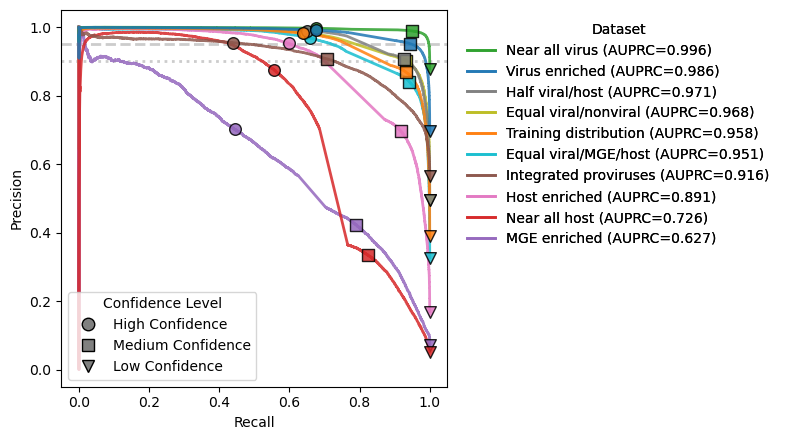

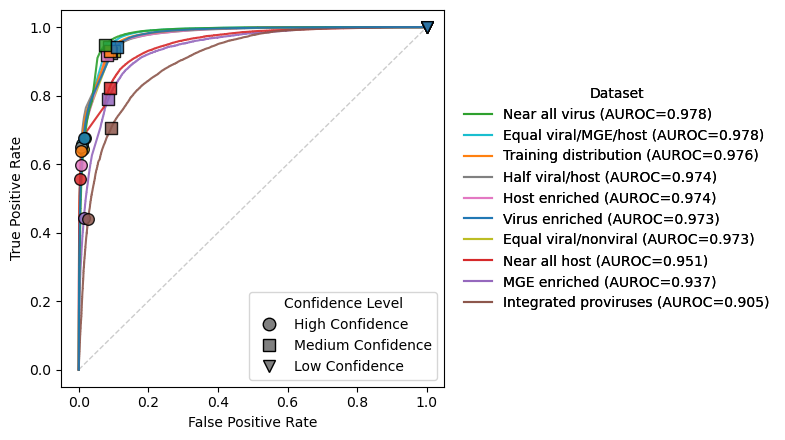

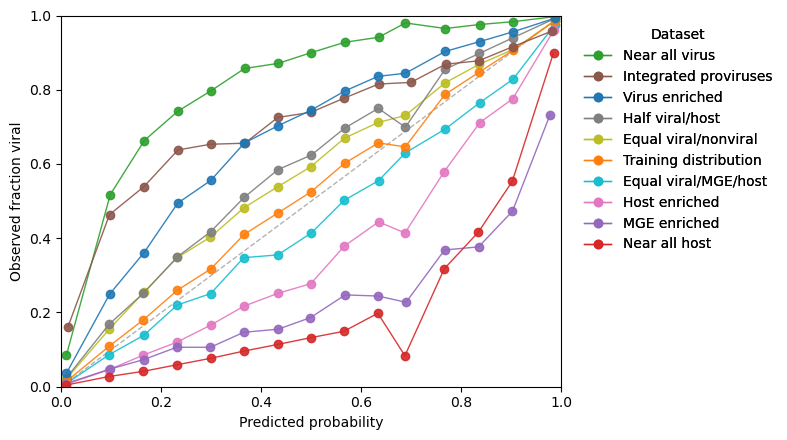

In [15]:
plot_pr_from_results(results)
plot_roc_from_results(results)
plot_reliability_from_results(results)

### Save plot points and AUPRC/AUROC values

In [16]:
def pr_points_df(complete_results):
    rows = []
    evals = complete_results["evaluation_results"]

    for internal, res in evals.items():
        dataset = _display_name(internal)

        prec = res["pr_curve"]["precision"]
        rec = res["pr_curve"]["recall"]

        for i, (r, p) in enumerate(zip(rec, prec)):
            rows.append({
                "dataset": dataset,
                "type": "curve",
                "idx": i,
                "recall": float(r),
                "precision": float(p),
                "confidence": None
            })

        pts = _confidence_triplet(res)
        for cname, (r, p) in pts.items():
            rows.append({
                "dataset": dataset,
                "type": "point",
                "idx": None,
                "recall": float(r),
                "precision": float(p),
                "confidence": cname
            })

    return pl.DataFrame(
        rows,
        schema={
            "dataset": pl.Utf8,
            "type": pl.Utf8,
            "idx": pl.Int64,
            "recall": pl.Float64,
            "precision": pl.Float64,
            "confidence": pl.Utf8
        }
    )

In [17]:
df_pr = pr_points_df(results)
df_pr

dataset,type,idx,recall,precision,confidence
str,str,i64,f64,f64,str
"""Equal viral/nonviral""","""curve""",0,1.0,0.495739,null
"""Equal viral/nonviral""","""curve""",1,1.0,0.49574,null
"""Equal viral/nonviral""","""curve""",2,1.0,0.495742,null
"""Equal viral/nonviral""","""curve""",3,1.0,0.495743,null
"""Equal viral/nonviral""","""curve""",4,1.0,0.495744,null
…,…,…,…,…,…
"""Virus enriched""","""curve""",343812,0.000003,1.0,null
"""Virus enriched""","""curve""",343813,0.0,1.0,null
"""Virus enriched""","""point""",null,0.674933,0.991319,"""High Confidence"""


In [18]:
df_pr.write_parquet(OUTPUT_TABLES_DIR.joinpath("lgbm_pr_points.parquet"))

In [19]:
def roc_points_df(complete_results):
    rows = []
    evals = complete_results["evaluation_results"]

    for internal, res in evals.items():
        dataset = _display_name(internal)

        fpr = res["roc_curve"]["fpr"]
        tpr = res["roc_curve"]["tpr"]

        for i, (f, t) in enumerate(zip(fpr, tpr)):
            rows.append({
                "dataset": dataset,
                "type": "curve",
                "idx": i,
                "fpr": float(f),
                "tpr": float(t),
                "confidence": None
            })

        for cname, key in [("High Confidence", "high_confidence"),
                           ("Medium Confidence", "medium_confidence"),
                           ("Low Confidence", "low_confidence")]:
            rows.append({
                "dataset": dataset,
                "type": "point",
                "idx": None,
                "fpr": float(1.0 - res[key]["tnr"]),
                "tpr": float(res[key]["tpr"]),
                "confidence": cname
            })

    return pl.DataFrame(
        rows,
        schema={
            "dataset": pl.Utf8,
            "type": pl.Utf8,
            "idx": pl.Int64,
            "fpr": pl.Float64,
            "tpr": pl.Float64,
            "confidence": pl.Utf8
        }
    )

In [20]:
df_roc = roc_points_df(results)
df_roc

dataset,type,idx,fpr,tpr,confidence
str,str,i64,f64,f64,str
"""Equal viral/nonviral""","""curve""",0,0.0,0.0,null
"""Equal viral/nonviral""","""curve""",1,0.0,0.000005,null
"""Equal viral/nonviral""","""curve""",2,0.0,0.000131,null
"""Equal viral/nonviral""","""curve""",3,0.000015,0.000131,null
"""Equal viral/nonviral""","""curve""",4,0.000015,0.000147,null
…,…,…,…,…,…
"""Virus enriched""","""curve""",57846,0.999915,1.0,null
"""Virus enriched""","""curve""",57847,1.0,1.0,null
"""Virus enriched""","""point""",null,0.013543,0.674933,"""High Confidence"""


In [21]:
df_roc.write_parquet(OUTPUT_TABLES_DIR.joinpath("lgbm_roc_points.parquet"))

In [22]:
def reliability_points_df(complete_results):
    rows = []
    evals = complete_results["evaluation_results"]

    for internal, res in evals.items():
        dataset = _display_name(internal)

        prob_true = res["reliability"]["prob_true"]
        prob_pred = res["reliability"]["prob_pred"]

        for i, (pp, pt) in enumerate(zip(prob_pred, prob_true)):
            rows.append({
                "dataset": dataset,
                "idx": i,
                "predicted_prob": float(pp),
                "observed_fraction": float(pt)
            })

    return pl.DataFrame(
        rows,
        schema={
            "dataset": pl.Utf8,
            "idx": pl.Int64,
            "predicted_prob": pl.Float64,
            "observed_fraction": pl.Float64
        }
    )

In [23]:
df_rel = reliability_points_df(results)
df_rel

dataset,idx,predicted_prob,observed_fraction
str,i64,f64,f64
"""Equal viral/nonviral""",0,0.009147,0.019686
"""Equal viral/nonviral""",1,0.096026,0.155556
"""Equal viral/nonviral""",2,0.164668,0.253893
"""Equal viral/nonviral""",3,0.232136,0.348148
"""Equal viral/nonviral""",4,0.298341,0.403175
…,…,…,…
"""Virus enriched""",10,0.688386,0.844451
"""Virus enriched""",11,0.767783,0.903091
"""Virus enriched""",12,0.836672,0.929574


In [24]:
df_rel.write_parquet(OUTPUT_TABLES_DIR.joinpath("lgbm_reliability_points.parquet"))

## Run model diagnostics

In [25]:
for key in results["datasets"].keys():
    if key != "train":
        print(f"\n--- Diagnostic report for {key} ---")
        ViralConfidencePredictor.diagnostic_report(
            results["trained_model"],
            eval_df = results["datasets"][key],
            train_df = results["datasets"]['train']
            )


--- Diagnostic report for test_equal_pos ---


2026-07-11 15:07:23 | PR-curve AUPRC (raw probs): 0.970
2026-07-11 15:09:43 | Top-5 permutation importance:
2026-07-11 15:09:43 | contig_avg_Pfam_VL-score      : 0.0805
2026-07-11 15:09:43 | contig_avg_KEGG_V-score       : 0.0332
2026-07-11 15:09:43 | contig_avg_Pfam_V-score       : 0.0242
2026-07-11 15:09:43 | contig_avg_PHROG_V-score      : 0.0233
2026-07-11 15:09:43 | contig_avg_KEGG_VL-score      : 0.0131
2026-07-11 15:10:08 | Ablation test (drop top 5 feats): F1 full 0.912 -> F1 ablated 0.909 Delta -0.003



--- Diagnostic report for test_equal_source ---


2026-07-11 15:10:08 | PR-curve AUPRC (raw probs): 0.955
2026-07-11 15:11:08 | Top-5 permutation importance:
2026-07-11 15:11:08 | contig_avg_Pfam_VL-score      : 0.0635
2026-07-11 15:11:08 | contig_avg_KEGG_V-score       : 0.0305
2026-07-11 15:11:08 | contig_avg_Pfam_V-score       : 0.0202
2026-07-11 15:11:08 | contig_avg_PHROG_V-score      : 0.0153
2026-07-11 15:11:08 | contig_avg_KEGG_VL-score      : 0.0138
2026-07-11 15:11:33 | Ablation test (drop top 5 feats): F1 full 0.912 -> F1 ablated 0.909 Delta -0.003



--- Diagnostic report for test_half_virus_host ---


...

2026-07-11 15:27:51 | PR-curve AUPRC (raw probs): 0.996
2026-07-11 15:34:57 | Top-5 permutation importance:
2026-07-11 15:34:57 | contig_avg_Pfam_VL-score      : 0.0478
2026-07-11 15:34:57 | contig_avg_Pfam_V-score       : 0.0243
2026-07-11 15:34:57 | contig_avg_PHROG_V-score      : 0.0228
2026-07-11 15:34:57 | contig_avg_KEGG_V-score       : 0.0214
2026-07-11 15:34:57 | KEGG_viral_left_dist          : 0.0178
2026-07-11 15:35:53 | Ablation test (drop top 5 feats): F1 full 0.912 -> F1 ablated 0.909 Delta -0.003



--- Diagnostic report for test_provirus ---


2026-07-11 15:35:53 | PR-curve AUPRC (raw probs): 0.916
2026-07-11 15:37:14 | Top-5 permutation importance:
2026-07-11 15:37:14 | contig_avg_Pfam_VL-score      : 0.0295
2026-07-11 15:37:14 | window_avg_Pfam_VL-score      : 0.0223
2026-07-11 15:37:14 | window_avg_KEGG_VL-score      : 0.0176
2026-07-11 15:37:14 | contig_avg_PHROG_V-score      : 0.0166
2026-07-11 15:37:14 | Pfam_VL-score                 : 0.0137
2026-07-11 15:38:24 | Ablation test (drop top 5 feats): F1 full 0.912 -> F1 ablated 0.908 Delta -0.004



--- Diagnostic report for test_virus_enriched ---


2026-07-11 15:38:27 | PR-curve AUPRC (raw probs): 0.987
2026-07-11 15:42:15 | Top-5 permutation importance:
2026-07-11 15:42:15 | contig_avg_Pfam_VL-score      : 0.0753
2026-07-11 15:42:15 | contig_avg_KEGG_V-score       : 0.0285
2026-07-11 15:42:15 | contig_avg_PHROG_V-score      : 0.0263
2026-07-11 15:42:15 | contig_avg_Pfam_V-score       : 0.0247
2026-07-11 15:42:15 | KEGG_viral_left_dist          : 0.0125
2026-07-11 15:43:15 | Ablation test (drop top 5 feats): F1 full 0.912 -> F1 ablated 0.909 Delta -0.003


## Write test dataset tables with their fitted LGBM probablities/thresholds

In [26]:
thresholds = results["model_summary"]["confidence_thresholds"]
test_dfs_with_lgbm_results = {}
for df_name in results["datasets"].keys():
    if df_name != "train":
        df = results["datasets"][df_name].copy().drop(["Viral_Origin_Confidence"], axis=1, errors="ignore")
        df["LGBM_probability"] = results["evaluation_results"][df_name]["probabilities"]
        df["LGBM_Viral_Origin_Confidence"] = "low"
        df.loc[df["LGBM_probability"] >= thresholds["medium"], "LGBM_Viral_Origin_Confidence"] = "medium"
        df.loc[df["LGBM_probability"] >= thresholds["high"], "LGBM_Viral_Origin_Confidence"] = "high"
        test_dfs_with_lgbm_results[df_name] = df

In [27]:
for name, df in test_dfs_with_lgbm_results.items():
    out = OUTPUT_TABLES_DIR.joinpath(f"{name}_with_lgbm_results.parquet")
    df.to_parquet(out, index=False)
    ! du -sh {out}

24M	tables/lgbm/test_equal_pos_with_lgbm_results.parquet
13M	tables/lgbm/test_equal_source_with_lgbm_results.parquet
38M	tables/lgbm/test_half_virus_host_with_lgbm_results.parquet
22M	tables/lgbm/test_host_enriched_with_lgbm_results.parquet
58M	tables/lgbm/test_input_with_lgbm_results.parquet
15M	tables/lgbm/test_mge_enriched_with_lgbm_results.parquet
44M	tables/lgbm/test_near_all_host_with_lgbm_results.parquet
45M	tables/lgbm/test_near_all_virus_with_lgbm_results.parquet
5.4M	tables/lgbm/test_provirus_with_lgbm_results.parquet
25M	tables/lgbm/test_virus_enriched_with_lgbm_results.parquet


## Write the LGBM files to `.joblib`

In [28]:
from pathlib import Path
JOBLIB_OUT = Path("../CheckAMG/files")

In [29]:
from joblib import dump
dump(model.model, JOBLIB_OUT.joinpath("lgbm_model.joblib"), compress=3)
dump(model.confidence_thresholds, JOBLIB_OUT.joinpath("lgbm_thresholds.joblib"), compress=3)
dump(model.feature_names, JOBLIB_OUT.joinpath("lgbm_feature_names.joblib"), compress=3)

['../CheckAMG/files/lgbm_feature_names.joblib']

In [30]:
! du -sh {JOBLIB_OUT}/*.joblib

4.0K	../CheckAMG/files/lgbm_feature_names.joblib
5.9M	../CheckAMG/files/lgbm_model.joblib
4.0K	../CheckAMG/files/lgbm_thresholds.joblib


## Compare LGBM predictions to just the strict/ambiguous viral region predictions

In [31]:
import pandas as pd

def _safe_div(a, b):
    import numpy as np
    return float(a) / float(b) if b else np.nan

def _confusion_counts(y_true, y_pred_bool):
    import numpy as np
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred_bool).astype(bool)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    return tp, fp, tn, fn

def _metrics_from_confusion(tp, fp, tn, fn):
    import numpy as np

    total = tp + fp + tn + fn

    acc = _safe_div(tp + tn, total)
    tpr = _safe_div(tp, tp + fn)
    tnr = _safe_div(tn, tn + fp)
    fpr = _safe_div(fp, fp + tn)
    fnr = _safe_div(fn, fn + tp)

    precision = _safe_div(tp, tp + fp)
    npv = _safe_div(tn, tn + fn)
    fdr = _safe_div(fp, tp + fp)

    f1 = _safe_div(2 * precision * tpr, precision + tpr) if (precision + tpr) else np.nan

    denom = (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)
    mcc = ((tp * tn) - (fp * fn)) / (denom ** 0.5) if denom else np.nan

    bal_acc = np.nanmean([tpr, tnr])

    prevalence = _safe_div(tp + fn, total)

    return {
        "N_Total": total,
        "Predictions_Made": int(tp + fp),
        "Prevalence": prevalence,
        "Accuracy": acc,
        "Balanced_Accuracy": bal_acc,
        "TPR": tpr,
        "TNR": tnr,
        "FPR": fpr,
        "FNR": fnr,
        "Precision": precision,
        "Recall": tpr,
        "Specificity": tnr,
        "NPV": npv,
        "F1_Score": f1,
        "FDR": fdr,
        "MCC": mcc,
    }
    
def update_summary_with_confidence_x_step5(
    results: dict,
    summary_table: pd.DataFrame,
    step5_col: str = "step5_in_merged_region",
    dataset_col: str = "Dataset",
    true_label_key: str = "true_labels",
):

    summary = summary_table.copy()

    level_map = {
        "high": "High Confidence",
        "medium": "Medium Confidence",
        "low": "Low Confidence",
    }

    for ds, eval_res in results["evaluation_results"].items():

        if ds not in results["datasets"]:
            continue

        df = results["datasets"][ds]
        y_true = eval_res[true_label_key]

        step5 = df[step5_col].fillna(False).astype(bool).to_numpy()

        auroc = eval_res.get("roc_curve", {}).get("auroc", pd.NA)
        auprc = eval_res.get("pr_curve", {}).get("auprc", pd.NA)
        ece = eval_res.get("reliability", {}).get("ece", pd.NA)

        for level_key in ["high_confidence", "medium_confidence", "low_confidence"]:

            if level_key not in eval_res:
                continue

            block = eval_res[level_key]
            short_level = block.get("level")
            base_level = level_map.get(short_level, short_level)

            # Build base prediction mask for this confidence level
            tp, fp, tn, fn = block["tp"], block["fp"], block["tn"], block["fn"]

            # Reconstruct base predictions from confusion counts is unsafe.
            # Instead derive mask from threshold stored in block.
            threshold = block.get("threshold")

            if threshold is None:
                continue

            scores = eval_res["probabilities"]
            base_pred = (scores >= threshold)

            variants = {
                f"{base_level} x Step5=True": base_pred & step5,
                f"{base_level} x Step5=False": base_pred & (~step5),
                f"{base_level} x Step5=Either": base_pred,
            }

            for variant_name, pred_mask in variants.items():

                tp_v, fp_v, tn_v, fn_v = _confusion_counts(y_true, pred_mask)
                metrics = _metrics_from_confusion(tp_v, fp_v, tn_v, fn_v)

                row = {
                    dataset_col: ds,
                    "Viral_Fraction": summary_table.loc[summary_table[dataset_col] == ds, "Viral_Fraction"].iloc[0],
                    "MGE_Fraction": summary_table.loc[summary_table[dataset_col] == ds, "MGE_Fraction"].iloc[0],
                    "Host_Fraction": summary_table.loc[summary_table[dataset_col] == ds, "Host_Fraction"].iloc[0],
                    "Confidence_Level": base_level,
                    "Strict_Viral_Region": "True" if "Step5=True" in variant_name else ("False" if "Step5=False" in variant_name else "Either"),
                    "Threshold": threshold,
                    "AUROC": auroc,
                    "AUPRC": auprc,
                    "ECE": ece,
                    **metrics
                }

                summary = pd.concat([summary, pd.DataFrame([row])], ignore_index=True, sort=False)
                summary = summary.drop(["Meets_FDR_Target", "Meets_Recall_Target"], axis=1, errors="ignore")

    return summary

In [32]:
summary_strict_strat = update_summary_with_confidence_x_step5(results, summary_table, step5_col="step5_in_merged_region")
summary_strict_strat = summary_strict_strat[summary_strict_strat["FPR"].notna()]
summary_strict_strat["Dataset"] = summary_strict_strat["Dataset"].replace(name_map)

In [33]:
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 800):
    print(summary_strict_strat)

                   Dataset Viral_Fraction MGE_Fraction Host_Fraction   Confidence_Level Threshold  Predictions_Made  Accuracy Balanced_Accuracy       TPR       TNR Precision    Recall  F1_Score       FDR       MCC Strict_Viral_Region     AUROC     AUPRC       ECE   N_Total  Prevalence       FPR       FNR  Specificity       NPV
30    Equal viral/nonviral          50.0%        20.8%         29.2%    High Confidence      0.91             59087  0.654508          0.651569  0.306754  0.996384  0.988153  0.306754  0.468173  0.011847  0.420023                True  0.972598  0.967598  0.021069  383948.0    0.495739  0.003616  0.693246     0.996384  0.593823
31    Equal viral/nonviral          50.0%        20.8%         29.2%    High Confidence      0.91             65812  0.668012          0.665224  0.338041  0.992407  0.977664  0.338041  0.502378  0.022336    0.4384               False  0.972598  0.967598  0.021069  383948.0    0.495739  0.007593  0.661959     0.992407  0.603956
32    Equal v

In [34]:
summary_strict_strat.to_csv(OUTPUT_TABLES_DIR.joinpath("lgbm_benchmark_summary_table_strict_strat.tsv"), index=False, sep="\t")